In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
# An orderbook = two sides : bids (buyers) and asks (sellers)
# Each side = dict {price: volume}

bids = {99.5: 100, 99.0: 250, 98.5: 400}  # price -> volume
asks = {100.0: 150, 100.5: 300, 101.0: 200}

def mid_price(bids, asks):
    best_bid = max(bids.keys())
    best_ask = min(asks.keys())
    return (best_bid + best_ask) / 2

def spread(bids, asks):
    best_bid = max(bids.keys())
    best_ask = min(asks.keys())
    return best_ask - best_bid

print(f"Mid price : {mid_price(bids, asks)}")
print(f"Spread : {spread(bids, asks)}")

Mid price : 99.75
Spread : 0.5


In [4]:
# Simulate the 4 possible events
# 1. Limit order : add an order to the book
# 2. Market order : immediate execution at best price
# 3. Cancellation : delete existing order
# 4. Execution : matching one bid and one ask

def add_limit_order(book, price, volume):
    """Add or increase an order at a given price"""
    book[price] = book.get(price, 0) + volume
    return book

def cancel_order(book, price, volume):
    """Reduce or delete an order at a given price"""
    if price in book:
        book[price] = max(0, book[price] - volume)
        if book[price] == 0:
            del book[price]
    return book

def execute_market_order_buy(asks, volume):
    """Execute a buy order at best ask available"""
    best_ask = min(asks.keys())
    executed = min(volume, asks[best_ask])
    asks = cancel_order(asks, best_ask, executed)
    return asks, executed

def execute_market_order_sell(bids, volume):
    """Execute a sell order at best ask available"""
    best_bid = max(bids.keys())
    executed = min(volume, bids[best_bid])
    bids = cancel_order(bids, best_bid, executed)
    return bids, executed

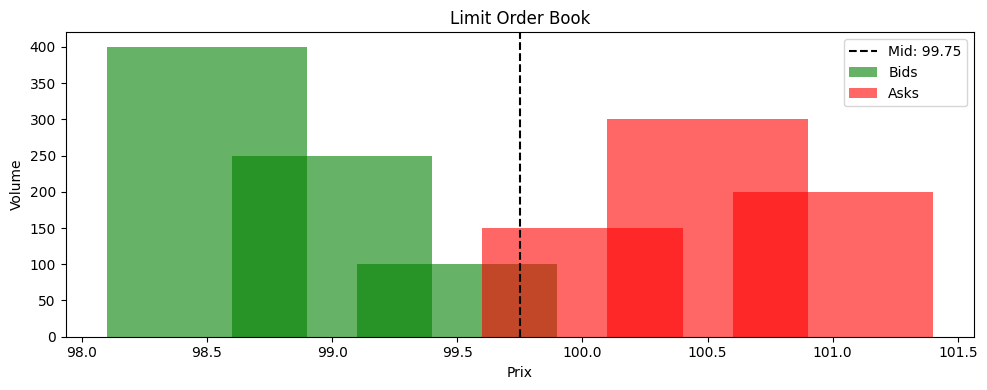

In [5]:
def plot_lob(bids, asks):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    bid_prices = sorted(bids.keys())
    ask_prices = sorted(asks.keys())
    
    ax.bar(bid_prices, [bids[p] for p in bid_prices], 
           color='green', alpha=0.6, label='Bids')
    ax.bar(ask_prices, [asks[p] for p in ask_prices], 
           color='red', alpha=0.6, label='Asks')
    
    ax.axvline(mid_price(bids, asks), color='black', 
               linestyle='--', label=f'Mid: {mid_price(bids, asks)}')
    ax.set_xlabel('Prix')
    ax.set_ylabel('Volume')
    ax.set_title('Limit Order Book')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_lob(bids, asks)